# Diabetes Risk Prediction — Data Loading & EDA

**Goal:** Understand the CDC Diabetes Health Indicators dataset before modeling.

Sections:
1. Load data
2. Basic checks (shape, types, missing values, duplicates)
3. Target variable / class balance
4. Feature distributions
5. Feature relationships with target
6. Key takeaways

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

In [17]:
!pip3 install -U ucimlrepo

## 1. Load Data

Option A: use the `ucimlrepo` package (recommended, handles versioning for you).
Option B: download the CSV directly if `ucimlrepo` gives you trouble.

In [3]:
from ucimlrepo import fetch_ucirepo

cdc_diabetes = fetch_ucirepo(id=891)

X = cdc_diabetes.data.features
y = cdc_diabetes.data.targets

df = pd.concat([X, y], axis=1)
print(df.shape)
df.head()

(253680, 22)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


In [5]:
print(cdc_diabetes.variables)

                    name     role     type      demographic  \
0                     ID       ID  Integer             None   
1        Diabetes_binary   Target   Binary             None   
2                 HighBP  Feature   Binary             None   
3               HighChol  Feature   Binary             None   
4              CholCheck  Feature   Binary             None   
5                    BMI  Feature  Integer             None   
6                 Smoker  Feature   Binary             None   
7                 Stroke  Feature   Binary             None   
8   HeartDiseaseorAttack  Feature   Binary             None   
9           PhysActivity  Feature   Binary             None   
10                Fruits  Feature   Binary             None   
11               Veggies  Feature   Binary             None   
12     HvyAlcoholConsump  Feature   Binary             None   
13         AnyHealthcare  Feature   Binary             None   
14           NoDocbcCost  Feature   Binary             

## 2. Basic Checks

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                253680 non-null  int64
 1   HighChol              253680 non-null  int64
 2   CholCheck             253680 non-null  int64
 3   BMI                   253680 non-null  int64
 4   Smoker                253680 non-null  int64
 5   Stroke                253680 non-null  int64
 6   HeartDiseaseorAttack  253680 non-null  int64
 7   PhysActivity          253680 non-null  int64
 8   Fruits                253680 non-null  int64
 9   Veggies               253680 non-null  int64
 10  HvyAlcoholConsump     253680 non-null  int64
 11  AnyHealthcare         253680 non-null  int64
 12  NoDocbcCost           253680 non-null  int64
 13  GenHlth               253680 non-null  int64
 14  MentHlth              253680 non-null  int64
 15  PhysHlth              253680 non-n

In [9]:
# Missing values
print('Missing values per column:')
print(df.isnull().sum().sort_values(ascending=False).head(10))

Missing values per column:
HighBP       0
HighChol     0
Income       0
Education    0
Age          0
Sex          0
DiffWalk     0
PhysHlth     0
MentHlth     0
GenHlth      0
dtype: int64


In [11]:
# Duplicate rows — known issue with this dataset
n_dupes = df.duplicated().sum()
print(f'Duplicate rows: {n_dupes} ({n_dupes / len(df):.1%} of data)')

df_clean = df.drop_duplicates().reset_index(drop=True)
print(f'Shape after dropping duplicates: {df_clean.shape}')

Duplicate rows: 24206 (9.5% of data)
Shape after dropping duplicates: (229474, 22)


## 3. Target Variable / Class Balance

Diabetes_binary
0    194377
1     35097
Name: count, dtype: int64
Diabetes_binary
0    84.7
1    15.3
Name: proportion, dtype: float64


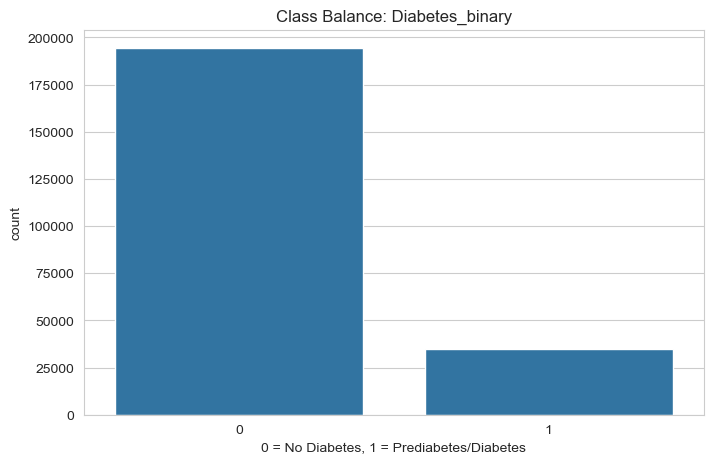

In [14]:
target_col = 'Diabetes_binary'

counts = df_clean[target_col].value_counts()
pct = df_clean[target_col].value_counts(normalize=True) * 100

print(counts)
print(pct.round(1))

sns.countplot(x=target_col, data=df_clean)
plt.title('Class Balance: Diabetes_binary')
plt.xlabel('0 = No Diabetes, 1 = Prediabetes/Diabetes')
plt.show()

## 4. Feature Distributions

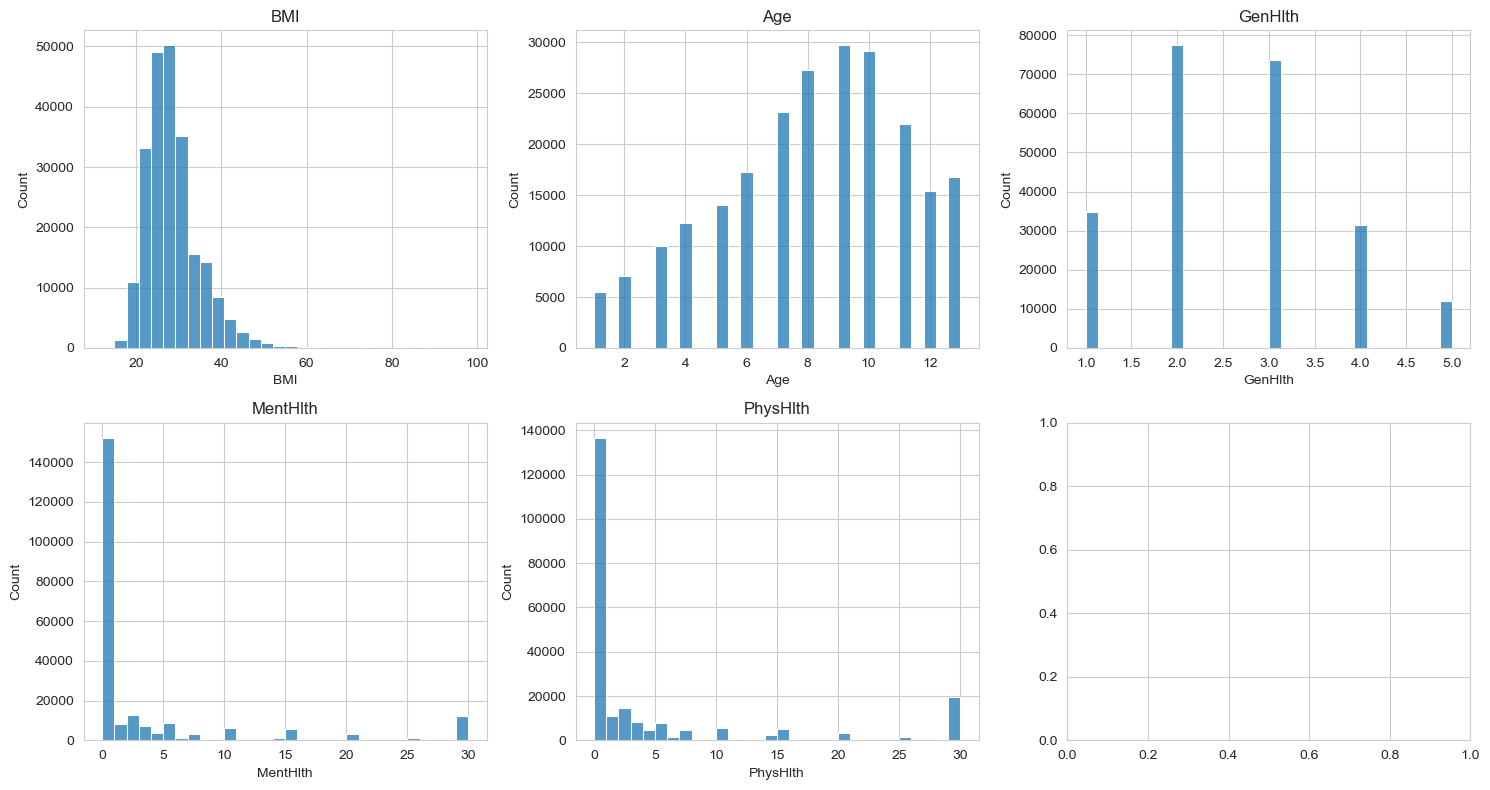

In [17]:
features_to_plot = ['BMI', 'Age', 'GenHlth', 'MentHlth', 'PhysHlth']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    if col in df_clean.columns:
        sns.histplot(df_clean[col], bins=30, ax=axes[i])
        axes[i].set_title(col)

plt.tight_layout()
plt.show()

## 5. Feature Relationships with Target

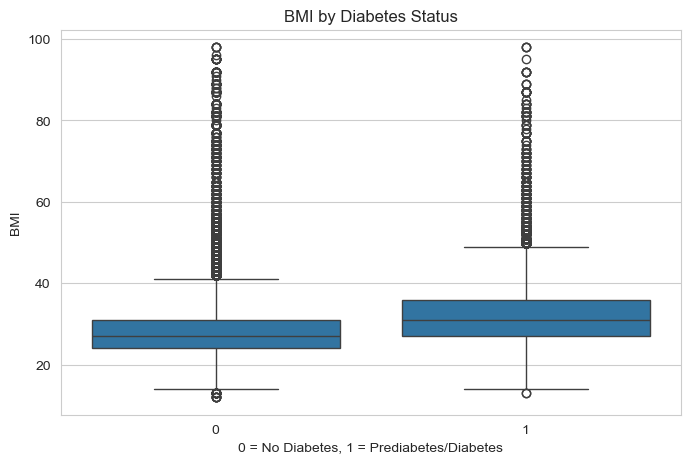

In [20]:
# Example: BMI by diabetes status
sns.boxplot(x=target_col, y='BMI', data=df_clean)
plt.title('BMI by Diabetes Status')
plt.xlabel('0 = No Diabetes, 1 = Prediabetes/Diabetes')
plt.show()

In [22]:
# Correlation of all features with the target (quick way to scan for strong signals)
corr_with_target = df_clean.corr(numeric_only=True)[target_col].sort_values(ascending=False)
print(corr_with_target)

Diabetes_binary         1.000000
GenHlth                 0.276940
HighBP                  0.254318
DiffWalk                0.205302
BMI                     0.205086
HighChol                0.194944
Age                     0.177263
HeartDiseaseorAttack    0.168213
PhysHlth                0.156211
Stroke                  0.099193
CholCheck               0.072523
MentHlth                0.054153
Smoker                  0.045504
Sex                     0.032724
AnyHealthcare           0.025331
NoDocbcCost             0.020048
Fruits                 -0.024805
Veggies                -0.041734
HvyAlcoholConsump      -0.065950
PhysActivity           -0.100404
Education              -0.102686
Income                 -0.140659
Name: Diabetes_binary, dtype: float64


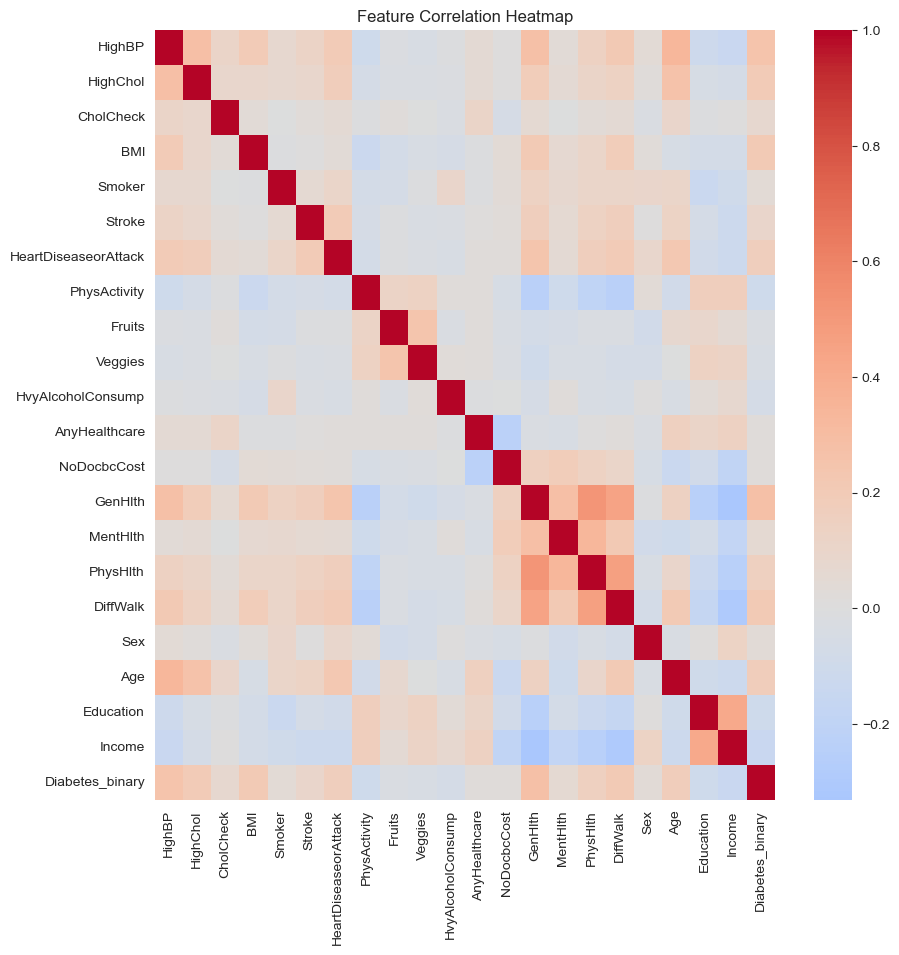

In [24]:
plt.figure(figsize=(10, 10))
sns.heatmap(df_clean.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

## 6. Key Takeaways

*(Fill this in as you explore — write 3-5 bullet points in plain English. This section,
not the code, is what most recruiters and interviewers will actually read.)*

- 
- 
- 

**Next notebook:** `02_feature_engineering_and_baseline_model.ipynb`